### Dataset 

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Apple SD Gothic Neo'

In [179]:
cols = ["engine_id", "cycle", "op1", "op2", "op3"] + [f"s{i}" for i in range(1, 22)]
train1 = pd.read_csv("../data/raw/train_FD001.txt", sep=r"\s+", header=None, names=cols)
train2 = pd.read_csv("../data/raw/train_FD002.txt", sep=r"\s+", header=None, names=cols)
train3 = pd.read_csv("../data/raw/train_FD003.txt", sep=r"\s+", header=None, names=cols)
train4 = pd.read_csv("../data/raw/train_FD004.txt", sep=r"\s+", header=None, names=cols)
test1 = pd.read_csv('../data/raw/test_FD001.txt',sep=r"\s+", header=None, names=cols)
test2 = pd.read_csv('../data/raw/test_FD002.txt',sep=r"\s+", header=None, names=cols)
test3 = pd.read_csv('../data/raw/test_FD003.txt',sep=r"\s+", header=None, names=cols)
test4 = pd.read_csv('../data/raw/test_FD004.txt',sep=r"\s+", header=None, names=cols)

In [182]:
train4.engine_id.nunique(), test4.engine_id.nunique(), len(open("../data/raw/RUL_FD004.txt").readlines())

(249, 248, 248)

In [176]:
train2

,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,164.31,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53754,260,312,20.0037,0.7000,100.0,491.19,608.79,1495.60,1269.51,9.35,...,314.05,2389.02,8169.64,9.3035,0.03,369,2324,100.00,24.36,14.5189
53755,260,313,10.0022,0.2510,100.0,489.05,605.81,1514.32,1324.12,10.52,...,371.22,2388.42,8245.36,8.7586,0.03,374,2319,100.00,28.10,16.9454
53756,260,314,25.0041,0.6200,60.0,462.54,537.48,1276.24,1057.92,7.05,...,163.74,2030.33,7971.25,11.0657,0.02,310,1915,84.93,14.19,8.5503
53757,260,315,25.0033,0.6220,60.0,462.54,537.84,1272.95,1066.30,7.05,...,164.37,2030.35,7972.47,11.0537,0.02,311,1915,84.93,14.05,8.3729


### train데이터에서의 각 열의 정보   
> 1열 : ID(총 100개의 센서)   
> 2열 : Cycle수   
> 3~5열 : 작동 조건(비행 고도, 스로틀 리졸버 각도 등)   
> 6~21열 : 센서 측정값(온도, 압력, 속도, 비율) 



In [157]:
train1.head(10).transpose() 

,0,1,2,3,4,5,6,7,8,9
engine_id,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
cycle,1.0000,2.0000,3.0000,4.0000,5.0000,6.0000,7.0000,8.0000,9.0000,10.0000
op1,-0.0007,0.0019,-0.0043,0.0007,-0.0019,-0.0043,0.0010,-0.0034,0.0008,-0.0033
op2,-0.0004,-0.0003,0.0003,0.0000,-0.0002,-0.0001,0.0001,0.0003,0.0001,0.0001
op3,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000
s1,518.6700,518.6700,518.6700,518.6700,518.6700,518.6700,518.6700,518.6700,518.6700,518.6700
s2,641.8200,642.1500,642.3500,642.3500,642.3700,642.1000,642.4800,642.5600,642.1200,641.7100
s3,1589.7000,1591.8200,1587.9900,1582.7900,1582.8500,1584.4700,1592.3200,1582.9600,1590.9800,1591.2400
s4,1400.6000,1403.1400,1404.2000,1401.8700,1406.2200,1398.3700,1397.7700,1400.9700,1394.8000,1400.4600
s5,14.6200,14.6200,14.6200,14.6200,14.6200,14.6200,14.6200,14.6200,14.6200,14.6200


- cycle열의 min, max값을 확인했을 때 최소 수명 1회, 최대 수명 362회인 것을 확인

### 제외 센서 : 값이 일정한 센서들(표준편차가 0이거나, mean, max, min값이 일정한 센서)
**FD001** : op1,op2,op3,s1,s5,s6,s10,s16,s18,s19 <br>
**FD002** : x<br>
**FD003** : op3,s1,s5,s16,s18,s19<br>
**FD004** : x<br>



In [158]:
train1_des = train1.describe()
train2_des = train2.describe()
train3_des = train3.describe()
train4_des = train4.describe()

In [187]:
train4_des.transpose()

,count,mean,std,min,25%,50%,75%,max
engine_id,61249.0,124.325181,71.995350,1.0000,60.0000,126.0000,185.0000,249.0000
cycle,61249.0,134.311417,89.783389,1.0000,62.0000,123.0000,191.0000,543.0000
op1,61249.0,23.999823,14.780722,0.0000,10.0046,25.0014,41.9981,42.0080
op2,61249.0,0.571347,0.310703,0.0000,0.2507,0.7000,0.8400,0.8420
op3,61249.0,94.031576,14.251954,60.0000,100.0000,100.0000,100.0000,100.0000
s1,61249.0,472.882435,26.436832,445.0000,445.0000,462.5400,491.1900,518.6700
s2,61249.0,579.420056,37.342647,535.4800,549.3300,555.7400,607.0700,644.4200
s3,61249.0,1417.896600,106.167598,1242.6700,1350.5500,1367.6800,1497.4200,1613.0000
s4,61249.0,1201.915359,119.327591,1024.4200,1119.4900,1136.9200,1302.6200,1440.7700
s5,61249.0,8.031626,3.622872,3.9100,3.9100,7.0500,10.5200,14.6200


### 엔진별 사이클 수명 분포
아이디별로 max값 만을 보아야함

In [160]:
life_cycle = train1.groupby('engine_id')['cycle'].max()

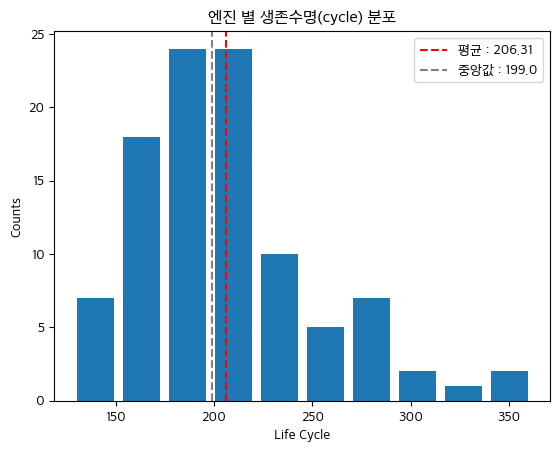

In [161]:
plt.hist(life_cycle,rwidth=0.8)
plt.xlabel('Life Cycle')
plt.ylabel('Counts')
plt.title('엔진 별 생존수명(cycle) 분포')
plt.axvline(life_cycle.mean(),linestyle='--',color='red',label=f'평균 : {life_cycle.mean()}')
plt.axvline(life_cycle.median(),linestyle='--',color='gray',label=f'중앙값 : {life_cycle.median()}')
plt.legend()

In [162]:
print(life_cycle.skew()) #왜도
print(life_cycle.kurtosis()) #첨도

1.0314712489551392
1.2341217576534755


왜도 = 1.03   
첨도 = 1.23

왜도와 첨도 모두 1점. 적당히 치우친 분포이다.

### 센서 통계

In [163]:
train_sensors_name = train1.columns[5:]

In [164]:
train1[train_sensors_name].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
s1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
s2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
s3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
s4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
s5,20631.0,14.620000,1.776400e-15,14.6200,14.6200,14.6200,14.6200,14.6200
s6,20631.0,21.609803,1.388985e-03,21.6000,21.6100,21.6100,21.6100,21.6100
s7,20631.0,553.367711,8.850923e-01,549.8500,552.8100,553.4400,554.0100,556.0600
s8,20631.0,2388.096652,7.098548e-02,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600
s9,20631.0,9065.242941,2.208288e+01,9021.7300,9053.1000,9060.6600,9069.4200,9244.5900
s10,20631.0,1.300000,0.000000e+00,1.3000,1.3000,1.3000,1.3000,1.3000


### 센서 별 열화 경향 

1번엔진 선택

센서 21개 서브플롯 그리드

센서마다 단위·스케일이 달라서(온도는 수백~수천, epr은 1 근처, rpm은 수천 등) 한 그래프에 겹쳐 그리면 스케일이 큰 센서만 보이고 나머지는 평평한 직선처럼 눌려 보인다. 그래서 센서마다 **자기 y축**을 갖는 그리드로 그려서, 절대값이 아니라 "추세가 있는가/없는가"를 비교한다.

In [171]:
def plot_sensor_grid(df, engine_id, subset_name="FD001", ncols=3, save_path=None):
    """엔진 하나의 21개 센서를 사이클에 따라 그리드로 그린다.
    각 서브플롯이 독립적인 y축을 쓰기 때문에, 센서 간 스케일 차이에 관계없이
    추세(오르는지/내리는지/그대로인지)를 한눈에 비교할 수 있다.
    """
    engine = df[df["engine_id"] == engine_id]
    sensor_cols = [f"s{i}" for i in range(1, 22)]
    nrows = -(-len(sensor_cols) // ncols)  # 올림 나눗셈

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.3 * nrows), sharex=True)
    axes = axes.flatten()

    for ax, col in zip(axes, sensor_cols):
        ax.plot(engine["cycle"], engine[col], linewidth=1, color="#4C72B0")
        ax.set_title(col, fontsize=10)
        ax.grid(True, linewidth=0.4, alpha=0.4)
        ax.tick_params(labelsize=8)

    for ax in axes[len(sensor_cols):]:
        ax.axis("off")

    fig.suptitle(f"{subset_name} - Engine {engine_id} - 21 sensors over cycles", fontsize=13)
    fig.supxlabel("cycle")
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    if save_path:
        fig.savefig(save_path, dpi=110)
    return fig

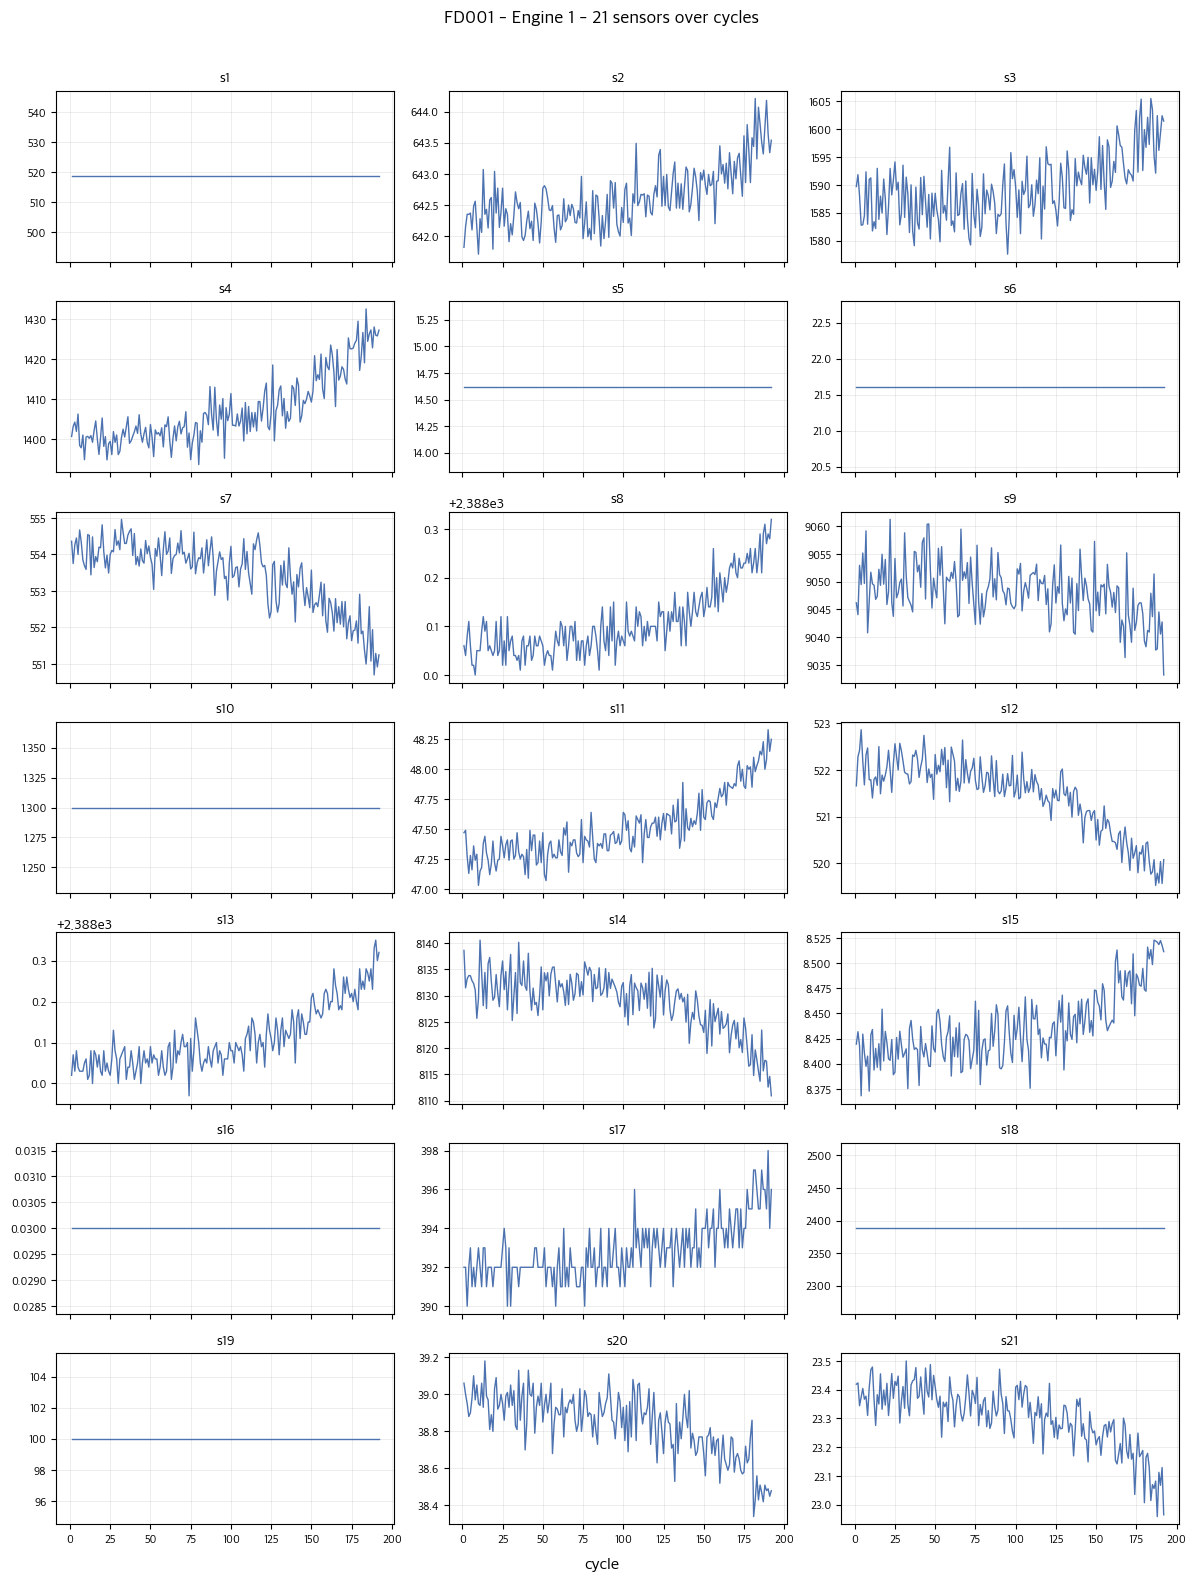

In [172]:
fig = plot_sensor_grid(train1, engine_id=1)

## engine 1 기준 1차 관찰 [확인 필요: 다른 엔진·다른 하위셋에서도 같은지 검증 안 됨]

- **완전히 평평한(값이 안 변하는) 센서**: s1, s5, s6, s10, s16, s18, s19 (7개) — 예측에 불필요함 = 제거
- **뚜렷하게 증가하는 센서**: s2, s3, s4, s8, s11, s13, s15, s17
- **뚜렷하게 감소하는 센서**: s7, s9, s12, s14, s20, s21

**다음 확인할 것**: 이 패턴이 engine 1만의 특징인지, 아니면 다른 엔진들도 똑같은 센서에서 평평함/증가/감소가 나타나는지 — 여러 엔진을 같은 서브플롯에 겹쳐서 확인해야 한다.

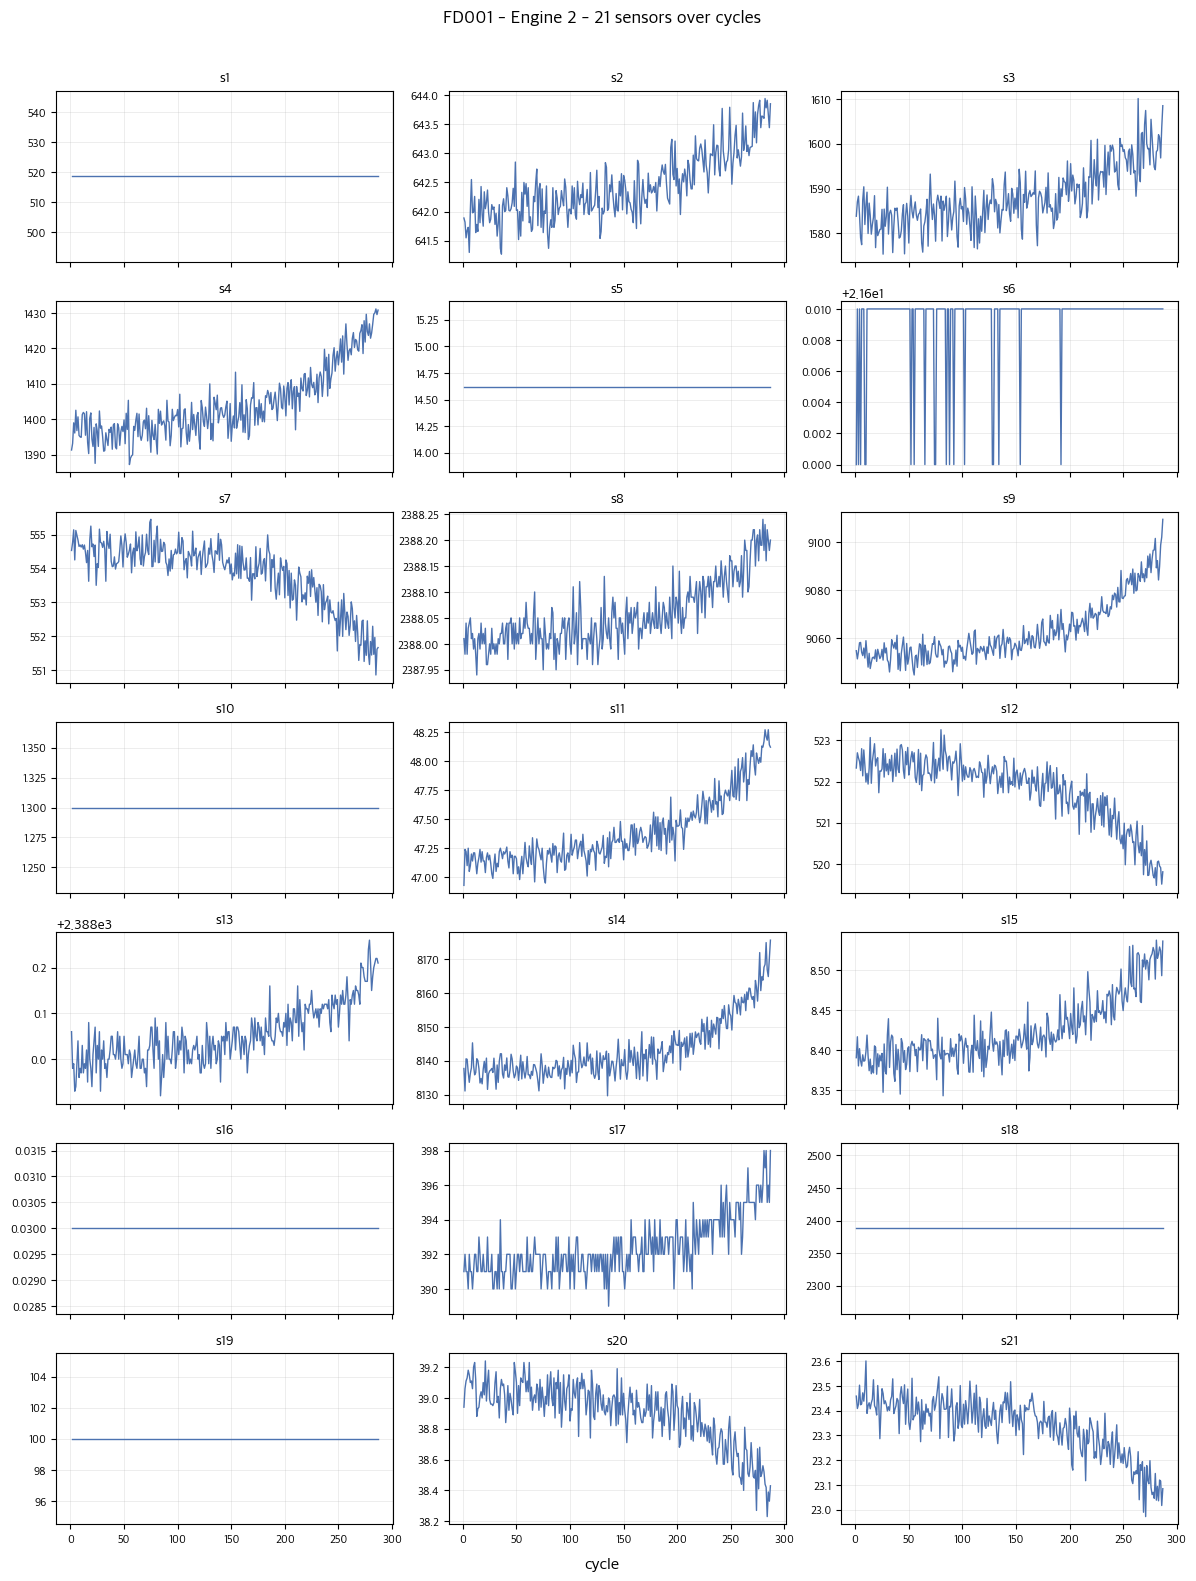

In [173]:
fig = plot_sensor_grid(train1, engine_id=2)

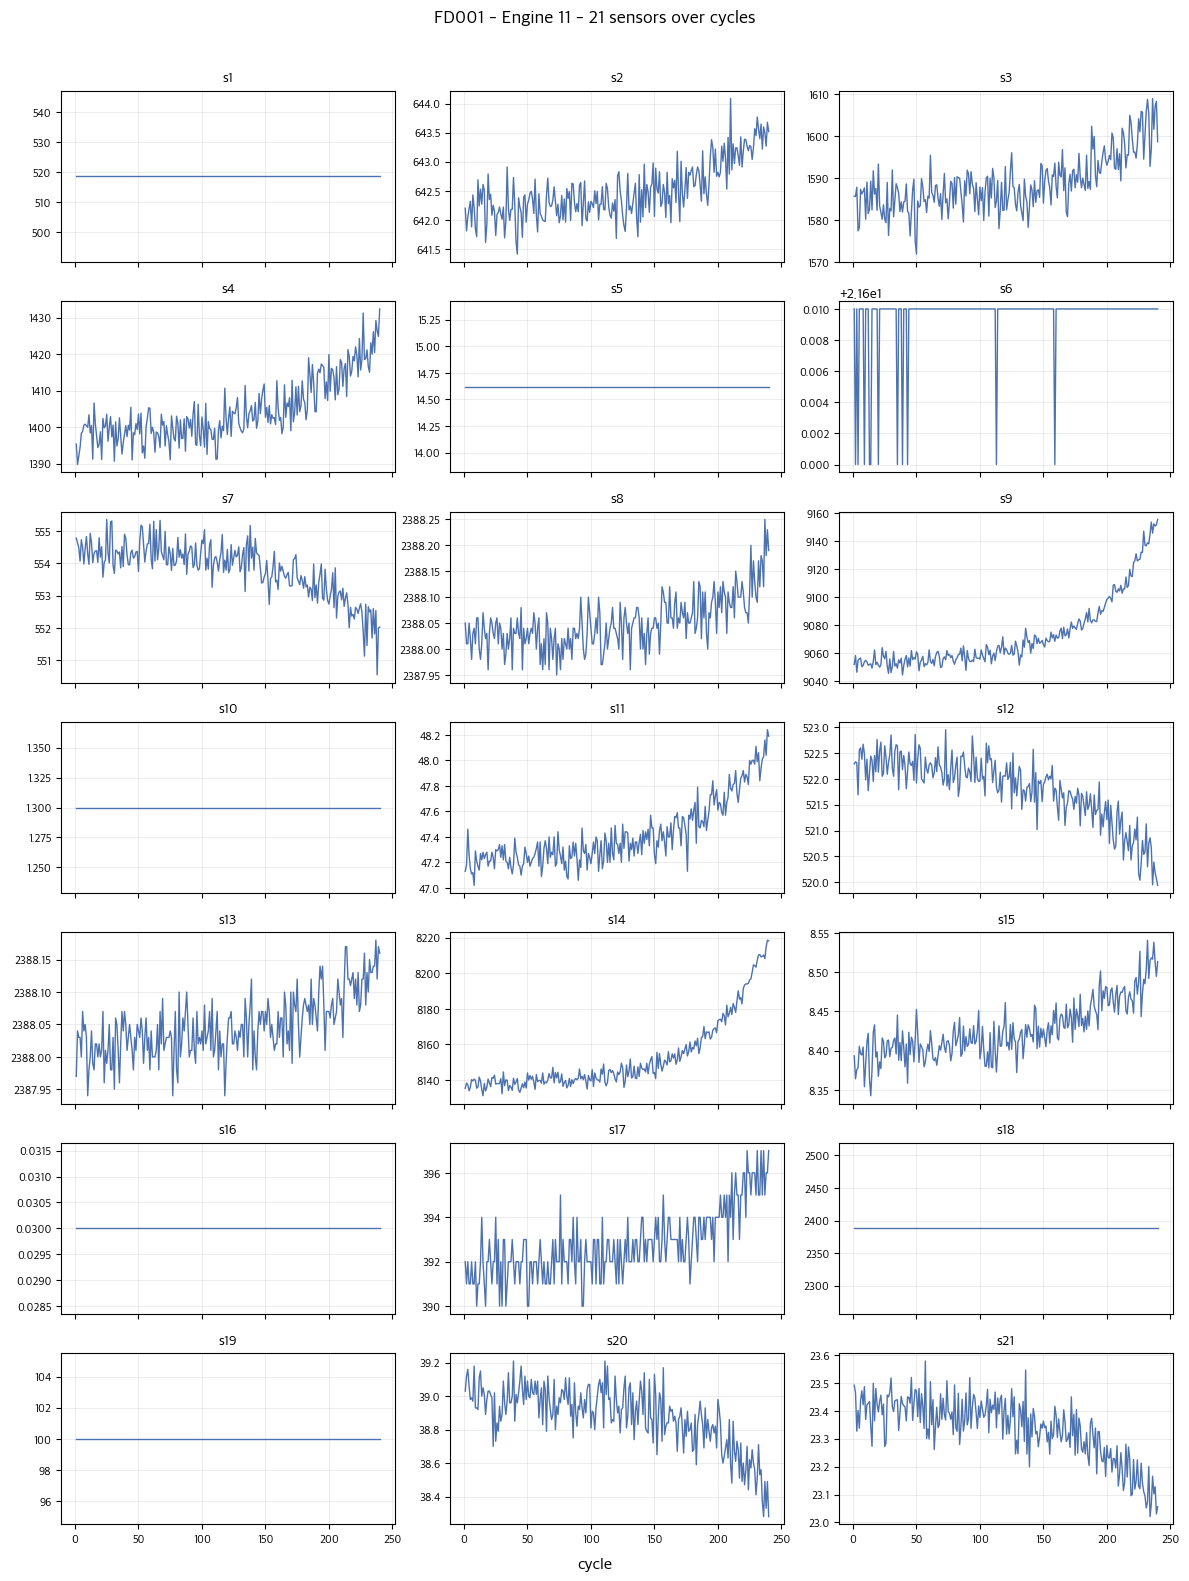

In [183]:
fig = plot_sensor_grid(train1, engine_id=11)